# ==========================================================
# EXPLICACIÓN DEL ALGORITMO GENÉTICO
# ==========================================================
#
# El Algoritmo Genético es una metaheurística inspirada en
# el proceso de evolución natural. En lugar de trabajar con
# una sola solución, mantiene una población de rutas que
# evolucionan durante varias generaciones.
#
# Cada ruta representa un individuo de la población y su
# calidad se evalúa mediante la distancia total recorrida
# en el problema TSP.
#
# El proceso general es:
#
# 1) Crear una población inicial de rutas aleatorias.
#
# 2) Evaluar el costo de cada ruta.
#
# 3) Seleccionar las mejores soluciones para reproducirse.
#
# 4) Combinar rutas mediante crossover para crear hijos.
#
# 5) Aplicar mutaciones aleatorias para generar diversidad.
#
# 6) Repetir el proceso durante varias generaciones.
#
# El objetivo es que las mejores características de las
# rutas se transmitan a los nuevos individuos, mejorando
# progresivamente la calidad de la población.
#
#
# ---------------------------
# PARÁMETROS UTILIZADOS
# ---------------------------
#
# Tamaño de población = 20
#
# Se generan 20 rutas simultáneamente en cada generación.
# Este valor permite mantener diversidad suficiente sin
# aumentar excesivamente el tiempo de ejecución.
#
# Si se utilizara una población pequeña (5 o 10 individuos),
# el algoritmo sería más rápido pero podría converger
# prematuramente a soluciones de baja calidad.
#
# Si se utilizara una población muy grande (100 o más),
# aumentaría la exploración del espacio de búsqueda pero
# también crecería considerablemente el tiempo de cálculo.
#
#
# Iteraciones = 100
#
# Representan la cantidad de generaciones que evolucionará
# la población.
#
# Un valor bajo puede detener la búsqueda antes de encontrar
# buenas soluciones.
#
# Un valor muy alto aumenta el tiempo de ejecución y suele
# producir mejoras cada vez más pequeñas.
#
#
# Élite = 5
#
# Las 5 mejores rutas de cada generación pasan
# directamente a la siguiente generación sin sufrir cambios.
#
# Esto evita perder soluciones de alta calidad que ya fueron
# encontradas.
#
# Se eligió un valor de 5 porque representa aproximadamente
# un 25% de la población total, manteniendo un equilibrio
# entre conservar buenas soluciones y permitir diversidad.
#
# Si la élite fuera muy pequeña podría perderse una buena
# solución.
#
# Si fuera muy grande, la población se volvería demasiado
# parecida y exploraría menos alternativas.
#
#
# Padres seleccionados = Top 10
#
# Los padres son escogidos entre las 10 mejores rutas de la
# población actual.
#
# Esto introduce presión selectiva, favoreciendo que las
# mejores soluciones tengan mayores probabilidades de
# reproducirse.
#
# Si solamente se utilizaran los 2 o 3 mejores individuos,
# la diversidad disminuiría rápidamente.
#
# Utilizar las 10 mejores rutas permite mantener variedad
# sin dejar de favorecer las soluciones de calidad.
#
#
# Probabilidad de mutación = 20%
#
# La mutación consiste en intercambiar dos ciudades dentro
# de una ruta.
#
# Su función es introducir diversidad genética y evitar que
# toda la población termine siendo idéntica.
#
# Con una mutación demasiado baja (1% o 2%), el algoritmo
# podría quedar atrapado en óptimos locales.
#
# Con una mutación demasiado alta (80% o 100%), las buenas
# características heredadas se destruirían constantemente y
# la búsqueda se volvería casi aleatoria.
#
# El valor de 20% es ampliamente utilizado porque entrega
# un buen equilibrio entre exploración y explotación.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import math
import time

ciudades = np.array([

    # Grupo A
    (10,10),
    (12,11),
    (11,13),
    (14,12),

    # Grupo B
    (45,45),
    (47,46),
    (44,48),
    (46,50),

    # Grupo C
    (85,15),
    (88,18),
    (86,21),
    (90,17),

    # Ciudades puente
    (30,25),
    (60,30),

    # Ciudades conflictivas
    (55,70),
    (25,60)

])

n_ciudades = len(ciudades)

print("Cantidad de ciudades:", n_ciudades)

Cantidad de ciudades: 16


In [2]:
def distancia(a, b):
    return np.linalg.norm(a - b)

In [3]:
dist_matrix = np.array([
    [distancia(ciudades[i], ciudades[j]) for j in range(n_ciudades)]
    for i in range(n_ciudades)
])

In [4]:
def costo(ruta):
    return sum(dist_matrix[ruta[i]][ruta[i+1]] for i in range(len(ruta)-1)) + dist_matrix[ruta[-1]][ruta[0]]

In [5]:
def plot_ruta(ruta, titulo="Ruta"):
    r = np.array([ciudades[i] for i in ruta] + [ciudades[ruta[0]]])

    plt.figure()
    plt.plot(r[:,0], r[:,1], marker='o')
    plt.title(titulo)
    plt.show()

In [6]:
def generar_vecino(ruta):
    vecino = ruta[:]
    i, j = random.sample(range(n_ciudades), 2)
    vecino[i], vecino[j] = vecino[j], vecino[i]
    return vecino

In [7]:
def crear_poblacion(tamano=20):
    base = list(range(n_ciudades))
    return [random.sample(base, n_ciudades) for _ in range(tamano)]

In [8]:
def crossover(padre1, padre2):
    corte = random.randint(1, n_ciudades - 2)
    hijo = padre1[:corte] + [x for x in padre2 if x not in padre1[:corte]]
    return hijo

# CROSSOVER (CRUCE)
#
# El crossover es el mecanismo mediante el cual dos rutas
# intercambian información para generar una nueva solución.
#
# Primero se selecciona un punto de corte aleatorio.
#
# La primera parte de la ruta del hijo se copia desde el
# padre 1.
#
# Posteriormente se recorren las ciudades del padre 2 y se
# agregan únicamente aquellas que aún no aparecen en el hijo.
#
# De esta forma se obtiene una ruta válida sin ciudades
# repetidas y que contiene características heredadas de
# ambos padres.
#
# El objetivo del crossover es combinar partes prometedoras
# de distintas soluciones para generar rutas potencialmente
# mejores que las de sus progenitores.
#
# Sin crossover, el algoritmo dependería únicamente de las
# mutaciones aleatorias y perdería gran parte de su capacidad
# evolutiva.

In [9]:
def mutacion(individuo):
    i, j = random.sample(range(n_ciudades), 2)
    individuo[i], individuo[j] = individuo[j], individuo[i]
    return individuo

# MUTACIÓN
#
# La mutación es el mecanismo encargado de introducir
# diversidad dentro de la población.
#
# Consiste en seleccionar dos posiciones aleatorias de la
# ruta e intercambiar sus ciudades.
#
# Su objetivo es evitar que todas las soluciones se vuelvan
# demasiado similares y permitir la exploración de nuevas
# regiones del espacio de búsqueda.
#
# En este algoritmo se utiliza una probabilidad de mutación
# del 20%, lo que significa que aproximadamente 1 de cada 5
# hijos generados sufrirá una modificación aleatoria.
#
# Si la mutación fuera demasiado baja, el algoritmo podría
# quedar atrapado en óptimos locales debido a la falta de
# diversidad.
#
# Si fuera demasiado alta, las buenas características
# heredadas mediante crossover se destruirían continuamente,
# transformando la búsqueda en un proceso casi aleatorio.
#
# Por esta razón se eligió un valor intermedio del 20%,
# buscando un equilibrio entre exploración y explotación.

In [10]:
def algoritmo_genetico(iteraciones=100):
    poblacion = crear_poblacion()

    for _ in range(iteraciones):
        poblacion = sorted(poblacion, key=costo)

        nueva_poblacion = poblacion[:5]  # élite

        while len(nueva_poblacion) < len(poblacion):
            padre1, padre2 = random.sample(poblacion[:10], 2)
            hijo = crossover(padre1, padre2)

            if random.random() < 0.2:
                mutacion(hijo)

            nueva_poblacion.append(hijo)

        poblacion = nueva_poblacion

    return min(poblacion, key=costo)

===== ALGORITMO GENÉTICO =====

Ruta encontrada:
[5, 7, 14, 15, 2, 0, 1, 3, 8, 9, 11, 10, 13, 12, 4, 6]

Costo total:
287.25

Cantidad de ciudades:
16

Tamaño de población:
20

Iteraciones:
100

Élite conservada:
5

Probabilidad de mutación:
20%

Tiempo:
0.0436 segundos


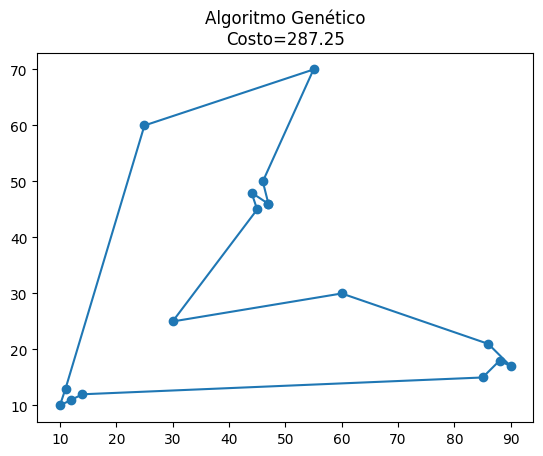

In [11]:
inicio = time.time()

mejor_ruta = algoritmo_genetico(iteraciones=100)

fin = time.time()

tiempo_total = fin - inicio

print("===== ALGORITMO GENÉTICO =====\n")

print("Ruta encontrada:")
print(mejor_ruta)

print("\nCosto total:")
print(round(costo(mejor_ruta), 2))

print("\nCantidad de ciudades:")
print(n_ciudades)

print("\nTamaño de población:")
print(20)

print("\nIteraciones:")
print(100)

print("\nÉlite conservada:")
print(5)

print("\nProbabilidad de mutación:")
print("20%")

print("\nTiempo:")
print(round(tiempo_total, 4), "segundos")

plot_ruta(
    mejor_ruta,
    f"Algoritmo Genético\nCosto={round(costo(mejor_ruta),2)}"
)